# Logistic regression
Logistic regression is a method of regression that acts like a step function, providing a way to interpolate between two discrete values. It's main use is in classification, where it naturally creates a decision boundary, but it can also be used to perform regression as well in some scenarios (think of ecosystems with a carrying capacity, where the sigmoid naturally works to describe such a system).
In this notebook, we will investigate the mathematics behind logistic regression and manually compute the gradients, and utilize feature engineering to fit to much messier data. All of this will be done to predict a single dependent variable, if an indicator will go up or down based on anonymized features.

### Why is this important?
There are two reasons why this is important, one placed within the context of the competition itself (this notebook utilizes data from ) and the bigger, underlying reason. For the competition, this will allow us to create a stacked model system utilizing more models for ideally higher accuracy. While logistic regression by itself is difficult (random walk theory) to directly predict the variable, simply predicting if the stock price goes up or goes down is still valuable for the context of the competition - it allows us to combine and aggregate multiple estimates, and this logistic regression will help confirm if our estimate by more granular regressors of the price going up/down is correct or not. 
More generally, knowing if the price will go up or not of a stock is an infinite money hack - if we have this information and find that there is a correlation, we can simply short or buy stock according to whether we predict the stock price to go "up" or "down". 


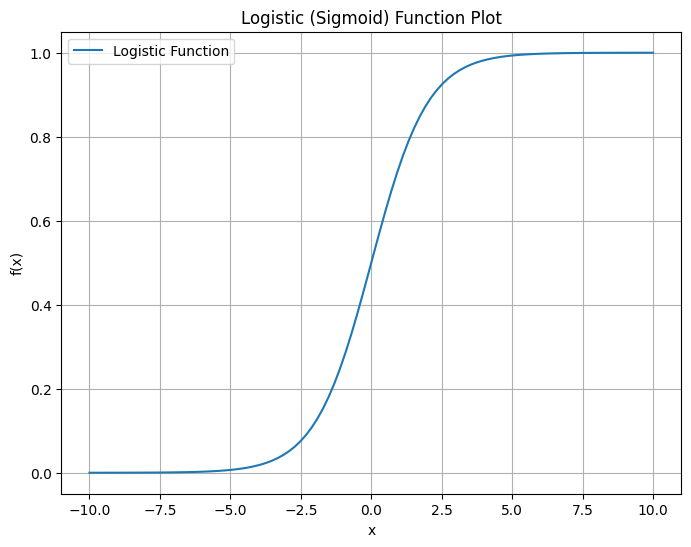

In [9]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import math as math
import pyarrow as pa
# imports all neccesary libraries, and plots a logistic function graph just to show what it looks like
def logistic_function(x):
    """
    Calculates the logistic (sigmoid) function.
    """
    return 1 / (1 + np.exp(-x))

# Example usage:
# Generate a range of x values
x_values = np.linspace(-10, 10, 100)

# Calculate the corresponding y values
y_values = logistic_function(x_values)

# Plot the function (optional)
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label='Logistic Function')
plt.title('Logistic (Sigmoid) Function Plot')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()



<center> An image of a logistic function, purely for decorative purposes</center>

## Part 0: Data
One of the most important things to know when doing any kind of data science is where the data is coming from - this will tell you a lot of information right off the bat.

This data was sourced from the ts-forecasting competition based on kaggle, and is a series of anonymized features to determine an indicator's magnitude (not an actual stock price). This data was likely pre-generated using some other machine learning model along with a LOT of added noise.

The competition was meant to be a predictive competition, with many, many indicators divided by code, subcode, and subcategory. As the data stands, it's still very difficult to use. First, we will seperate the data by horizon - the competition is meant to predict based on the horizons, 1, 3, 10, or 25 days in advance. For simplicity, only the 1 day horizon will be used - the same results apply to the 25th horizon as well.

Furthermore, the final data is not discrete. However, we can fix this by adding a new dummy column for whether the indicator's price went up or not compared to the last day, allowing us to make better educated guesses and allowing logistic regression to fit into a voting or boosting schema.
> As you will see, this will eventually end up being a poor idea - see https://psycnet.apa.org/doiLanding?doi=10.1037%2F1082-989X.7.1.19 for more detail on why artificially dichotomizing variables is generally silly. For now, we will live knowing that this strategy to complete the problem set was not the best idea. 
<br>
However, we also need to create many subdivisions - each category/subcategory is it's own "dataset" as well. As such, we'll start off by dividing the training data by horizon, then only work with horizon 1.

In [10]:
df = pl.read_parquet('./train.parquet')
# Polars uses expressions (pl.col) for filtering
df_h1  = df.filter(pl.col("horizon") == 1)
df_h3  = df.filter(pl.col("horizon") == 3)
df_h10 = df.filter(pl.col("horizon") == 10)
df_h25 = df.filter(pl.col("horizon") == 25)
print(df_h1.get_columns())

[shape: (1_394_653,)
Series: 'id' [str]
[
	"W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…
	"W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…
	"W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…
	"W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…
	"W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…
	…
	"83EG83KQ__R571RU17__PHHHVYZI__…
	"83EG83KQ__R571RU17__PHHHVYZI__…
	"83EG83KQ__R571RU17__PHHHVYZI__…
	"83EG83KQ__R571RU17__PHHHVYZI__…
	"83EG83KQ__R571RU17__PHHHVYZI__…
], shape: (1_394_653,)
Series: 'code' [str]
[
	"W2MW3G2L"
	"W2MW3G2L"
	"W2MW3G2L"
	"W2MW3G2L"
	"W2MW3G2L"
	…
	"83EG83KQ"
	"83EG83KQ"
	"83EG83KQ"
	"83EG83KQ"
	"83EG83KQ"
], shape: (1_394_653,)
Series: 'sub_code' [str]
[
	"J0G2B0KU"
	"J0G2B0KU"
	"J0G2B0KU"
	"J0G2B0KU"
	"J0G2B0KU"
	…
	"R571RU17"
	"R571RU17"
	"R571RU17"
	"R571RU17"
	"R571RU17"
], shape: (1_394_653,)
Series: 'sub_category' [str]
[
	"PZ9S1Z4V"
	"PZ9S1Z4V"
	"PZ9S1Z4V"
	"PZ9S1Z4V"
	"PZ9S1Z4V"
	…
	"PHHHVYZI"
	"PHHHVYZI"
	"PHHHVYZI"
	"PHHHVYZI"
	"PHHHVYZI"
], shape: (1_394_653,)
Series: 'horizon' [i32]
[
	1
	1
	1
	1
	1
	…
	1
	1
	1
	1
	1
], shape: (1_3

### Part 0: Correlation Coefficients & Feature Engineering
First, we need to start with identifying the variables that are possible to perform logistic regression on, compared to our new "up/down" binary classifier variable.

One of the key traits of this dataset is the existence of many "sub-datasets" within this dataset, making the dataset extremely large, forcing us to create subdivisions within categories, subcategories, etc. In total, there are over 100 different "sub-datasets", along with combinations of features and these sub-datasets. Generating scatter plots and manually checking would take way too long.

As such, we introduce the point-biserial correlation coefficient, similar to Pearson's correlation coefficient but for dichotomous (binary categorical) data. We will use this metric and apply it to all feature/subcategory combinations, saving values above 0.5 and with more than 30 samples to a table for later usage. (30 samples, because without enough samples it won't be statistically significant).

> The justification for this is quite simple: the formula itself is simply the mean of the IV for group 1 minus the mean of the IV for group 2, over the standard deviation and some additional normalization for assymetrical data groupings. The coefficient essentially shows you how much the means of the independent variables of group one differ from group two, and if they differ greatly, you can use the independent variable to help seperate the two groups.

In [146]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

# 1. Partition the data by the three divisions
# This creates a list of DFs isolated by the specific hierarchy
df_list = df_h1.partition_by(["code", "sub_code", "sub_category"])

high_corr_reports = []
df_list_final = []

# Select feature range
feature_cols = df_h1.select(pl.col("^feature_[a-c][a-z]$|^feature_ch$")).columns

for sub_df in df_list:
    # 2. Add 'is_up' logic inside the partition to avoid cross-contamination
    processed_df = (
        sub_df.sort("ts_index")
        .with_columns(
            is_up = (pl.col("y_target") > pl.col("y_target").shift(1)).cast(pl.Int8)
        )
    )
    
    clean_df = processed_df.drop_nulls(subset=["is_up"])
    if clean_df.height < 30 or clean_df["is_up"].n_unique() < 2:
        continue
        
    # Store for plotting later
    df_list_final.append(clean_df)

    # Get labels
    c_code = clean_df["code"][0]
    s_code = clean_df["sub_code"][0]
    s_cat  = clean_df["sub_category"][0]
    # 3. Check all features
    for col in feature_cols:
        # Avoid constant features or those with no variance
        if clean_df[col].std() == 0 or clean_df[col].null_count() == clean_df.height:
            continue
            
        corr, _ = pointbiserialr(clean_df["is_up"], clean_df[col])
        
        if abs(corr) > 0.5:
            high_corr_reports.append({
                "code": c_code,
                "sub_code": s_code,
                "sub_category": s_cat,
                "feature": col,
                "pbsc_score": corr
            })

# Save results
report_df = pd.DataFrame(high_corr_reports)
report_df.to_csv("high_correlation_audit.csv", index=False)
print(f"Audit complete. Found {len(report_df)} features with PBSC > 0.5")

Audit complete. Found 1969 features with PBSC > 0.5


For a more visual view, the following code has graphs of the top ten linear PBCC coefficients - you can see that there is a visual seperation between upwards and downwards trending movement, usually on feature_al.

Analyzing 1HEMHZK2 | 495MGHFJ | NQ58FVQM
Feature: feature_al | Data Length: 32 rows | PBSC: -0.7760


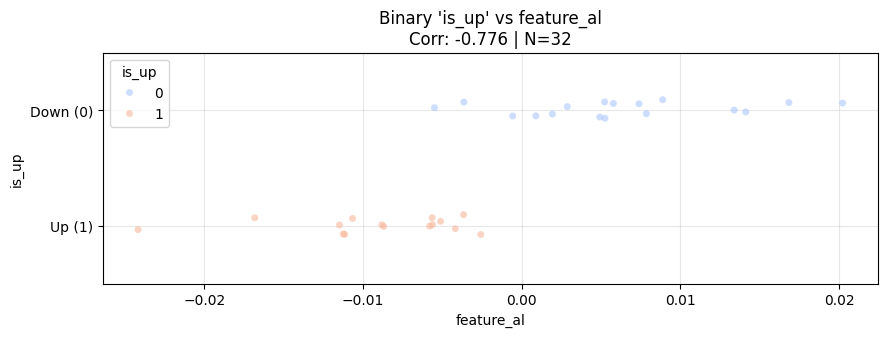

--------------------------------------------------
Analyzing VFWIFJPS | 0S17IW5Y | V8BKY1IV
Feature: feature_al | Data Length: 118 rows | PBSC: -0.7308


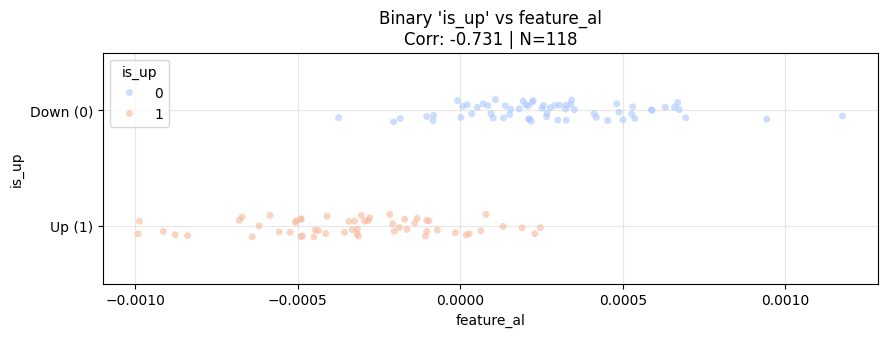

--------------------------------------------------
Analyzing CXEQN6KB | WN2GFZ9X | NQ58FVQM
Feature: feature_al | Data Length: 40 rows | PBSC: -0.7174


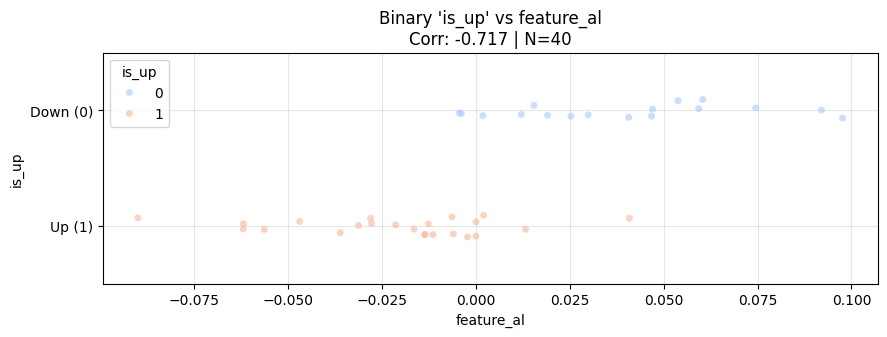

--------------------------------------------------
Analyzing W2MW3G2L | BHYOOVXQ | NQ58FVQM
Feature: feature_al | Data Length: 72 rows | PBSC: -0.7124


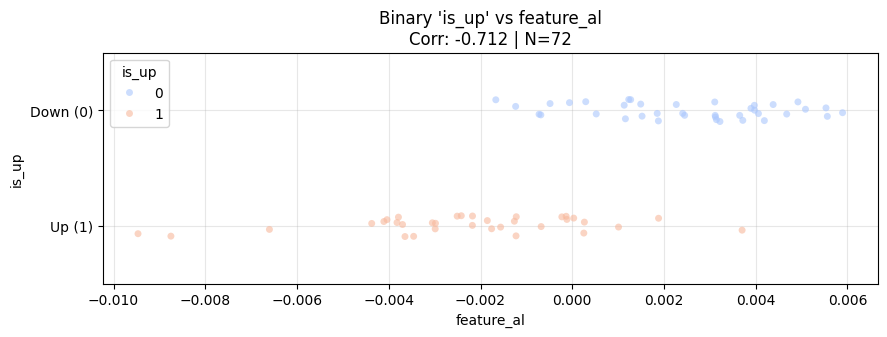

--------------------------------------------------
Analyzing W2MW3G2L | J0G2B0KU | NQ58FVQM
Feature: feature_al | Data Length: 51 rows | PBSC: -0.7114


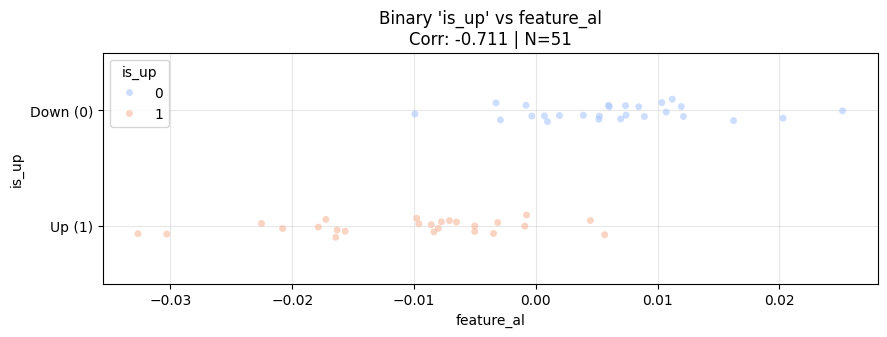

--------------------------------------------------
Analyzing W2MW3G2L | JJKGJ8KH | V8BKY1IV
Feature: feature_al | Data Length: 56 rows | PBSC: -0.7067


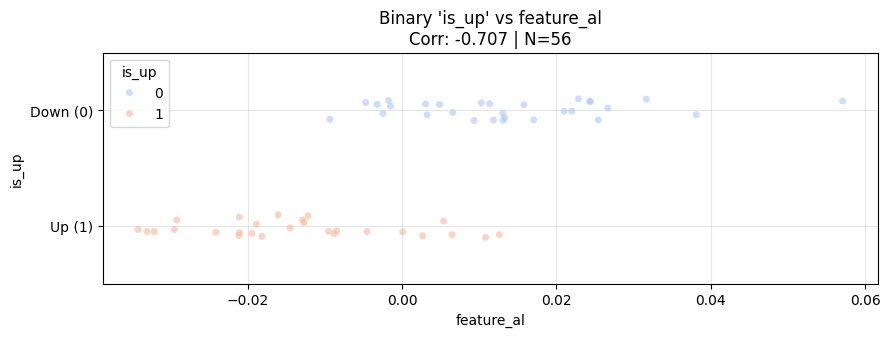

--------------------------------------------------
Analyzing 83EG83KQ | II90M002 | PHHHVYZI
Feature: feature_al | Data Length: 64 rows | PBSC: -0.7006


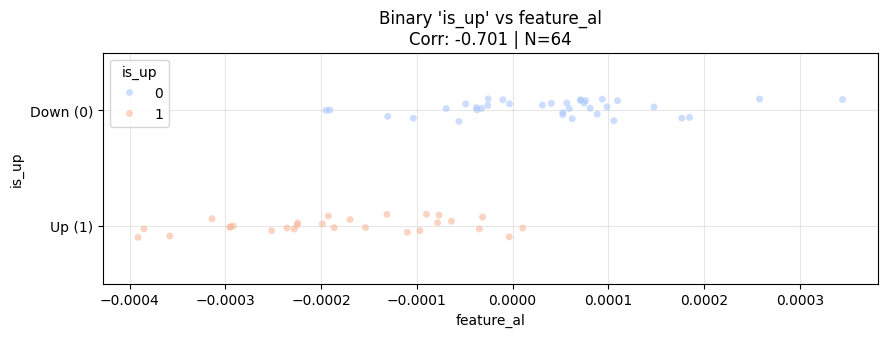

--------------------------------------------------
Analyzing EP12UF2K | 4K5656C0 | V8BKY1IV
Feature: feature_al | Data Length: 92 rows | PBSC: -0.6976


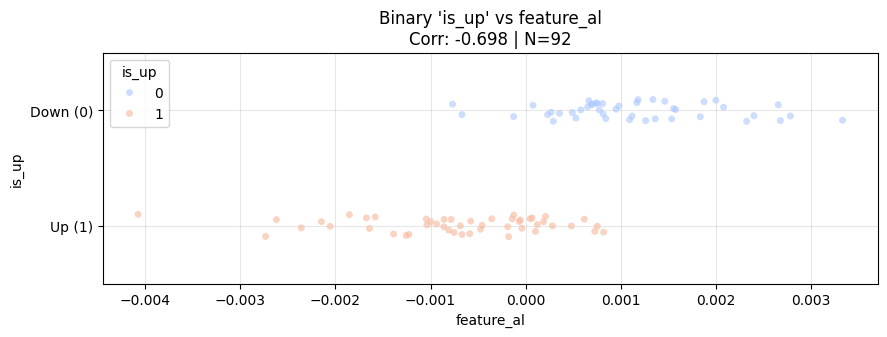

--------------------------------------------------
Analyzing 83EG83KQ | LZPGPFG6 | V8BKY1IV
Feature: feature_al | Data Length: 44 rows | PBSC: -0.6891


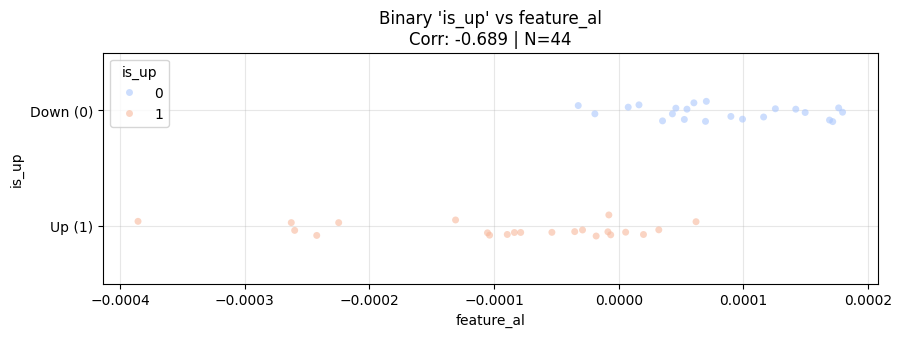

--------------------------------------------------
Analyzing CXEQN6KB | XLV1P2XM | V8BKY1IV
Feature: feature_al | Data Length: 41 rows | PBSC: -0.6808


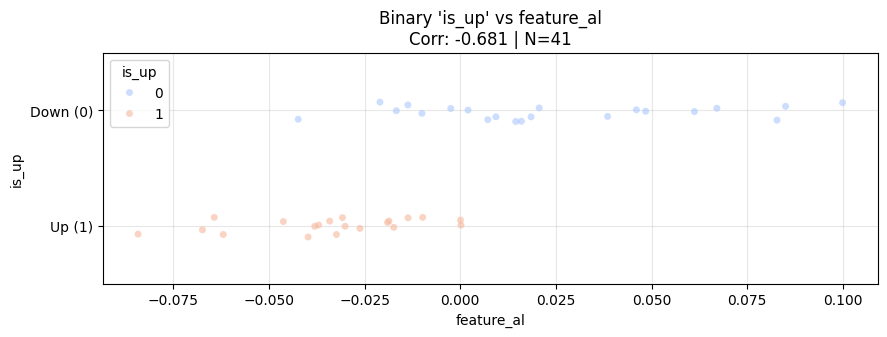

--------------------------------------------------


In [20]:
def plot_audit_visuals(df_list, report_df, max_plots=10):
    # Sort by strongest absolute correlation
    top_leads = report_df.sort_values(by="pbsc_score", key=abs, ascending=False).head(max_plots)
    
    for _, row in top_leads.iterrows():
        # Find matching DF in the list
        for sub_df in df_list:
            if (sub_df["code"][0] == row['code'] and 
                sub_df["sub_code"][0] == row['sub_code'] and 
                sub_df["sub_category"][0] == row['sub_category']):
                
                p_df = sub_df.to_pandas()
                data_length = len(p_df)
                
                # Print the metadata and data length
                print(f"Analyzing {row['code']} | {row['sub_code']} | {row['sub_category']}")
                print(f"Feature: {row['feature']} | Data Length: {data_length} rows | PBSC: {row['pbsc_score']:.4f}")
                
                plt.figure(figsize=(10, 3))
                
                # Plotting against 'is_up' (Binary Y-axis)
                # Adding 'jitter' helps visualize density if points overlap on the 0 or 1 line
                sns.stripplot(data=p_df, x=row['feature'], y='is_up', 
                              hue='is_up', palette='coolwarm', orient='h', alpha=0.6)
                
                plt.title(f"Binary 'is_up' vs {row['feature']}\nCorr: {row['pbsc_score']:.3f} | N={data_length}")
                plt.yticks([0, 1], ['Down (0)', 'Up (1)'])
                plt.grid(True, alpha=0.3)
                plt.show()
                print("-" * 50) # Visual separator for console output
                break
report_df = pd.read_csv("./high_correlation_audit.csv")
plot_audit_visuals(df_list_final, report_df)

### Part 1: Manual Implementation
Now that the data has been cleaned and some potential targets have been identified, we'll start off by manually implementing logistic regression, starting from implementing the sigmoid function, the cost function, the gradient function, and then implement gradient descent. We'll then test our manual implementation against numerical gradients and comparing it to scikit-learn's LogisticRegression.
First, we begin by defining the sigmoid function: instead of doing a singular variable, we instead vectorize it to provide an input of vectors, allowing us to perform operations over all features simultaneously.

In [4]:
import numpy as np
 # Corrected sigmoid function
def sigmoid(xs, thetas):
    """
    Calculates the logistic (sigmoid) function.
    Inputs:
        xs: Feature matrix (m, n+1) where m is the number of samples and n+1 is the number of features (including bias).
        thetas: Weight vector (n+1, 1).
    Output:
    A vector of probabilities (m, 1).
    """
    return 1 / (1 + np.exp(-np.dot(xs, thetas)))  # Use np.dot for matrix multiplication


Then, we define the cost and gradient functions as stated in the problem set. Our gradient function is simple - take steps using the vector of the gradient multiplied by the training speed for a certain number of iterations.

In [3]:
def cost_vectorized(IV, DV, thetas):
    m = len(DV)
    
    # Calculate predictions for all rows at once
    h = sigmoid(IV, thetas) 
    # prevents log of 0 from occuring
    epsilon = 1e-15
    
    # Calculate the total cost using vector multiplication
    total_cost = np.sum(DV * np.log(h + epsilon) + (1 - DV) * np.log(1 - h + epsilon))
    
    return -total_cost / m
import numpy as np

def compute_gradient(IV, DV, thetas):
    """
    Calculates the gradient of the logistic regression cost function.
    
    IV: Independent variables (feature matrix X)
    DV: Dependent variable (target vector y)
    thetas: Current weights
    """
    m = len(DV)
    
    # 1. Calculate predictions using the sigmoid function
    h = sigmoid(IV, thetas)
    
    # 2. Calculate the error (Prediction - Actual)
    error = h - DV
    
    # 3. Calculate the gradient using vectorized matrix multiplication
    # IV.T is the transpose of the feature matrix
    gradient = (1/m) * np.dot(IV.T, error)
    
    return gradient
def gradient_descent(IV, DV, thetas, learning_rate, num_iterations):
    """
    Performs gradient descent to learn thetas by taking num_iterations 
    gradient steps with learning_rate.
    """
    # Keep track of the cost at each step to plot later
    cost_history = []
    
    # Ensure thetas is a copy so we don't accidentally overwrite the original initial_thetas
    current_thetas = np.copy(thetas)
    
    for i in range(num_iterations):
        # 1. Compute the gradient for the current thetas
        grad = compute_gradient(IV, DV, current_thetas)
        
        # 2. Update the parameters (move in the opposite direction of the gradient)
        current_thetas = current_thetas - (learning_rate * grad)
        
        # 3. Compute the new cost and record it
        # (Assuming you are using the vectorized cost function we made earlier)
        current_cost = cost_vectorized(IV, DV, current_thetas)
        cost_history.append(current_cost)
        
        # Optional: Print progress every 10% of the iterations
        if i % (num_iterations // 10) == 0:
            print(f"Iteration {i:5d} | Cost: {current_cost:.4f}")
            
    return current_thetas, cost_history


We'll also define our numerical gradient checking function here, used later to confirm our gradients.
> The gradient, if *X* is $m \cdot n$, should be of dimensions $n \cdot 1$. This is logical - columns are features, so your gradient should align with the number of features you have. If this was not the case, these functions wouldn't be able to fit together - namely, IV and DV would have different dimensions and be incompatible.

In [12]:
def numerical_gradient_check(X, y, thetas, epsilon=1e-5):
    """
    Verifies the gradient computation using numerical approximation.
    Inputs:
        X: Feature matrix (m, n+1).
        y: Target vector (m, 1).
        thetas: Current weights (n+1, 1).
        epsilon: Small value for numerical approximation.
    Output:
        Numerical gradients (n+1, 1).
    """
    num_gradients = np.zeros_like(thetas)
    for i in range(len(thetas)):
        # Perturb theta[i] by epsilon
        thetas_plus = thetas.copy()
        thetas_minus = thetas.copy()
        thetas_plus[i] += epsilon
        thetas_minus[i] -= epsilon
        
        # Compute the cost for perturbed thetas
        cost_plus = -np.mean(y * np.log(sigmoid(X, thetas_plus) + 1e-15) + (1 - y) * np.log(1 - sigmoid(X, thetas_plus) + 1e-15))
        cost_minus = -np.mean(y * np.log(sigmoid(X, thetas_minus) + 1e-15) + (1 - y) * np.log(1 - sigmoid(X, thetas_minus) + 1e-15))
        
        # Compute numerical gradient
        num_gradients[i] = (cost_plus - cost_minus) / (2 * epsilon)
    
    return num_gradients

## Part 2: Single Feature Classification
Now we will actually utilize all of the functions we just wrote!
We begin by simply implementing our gradient descent function and training it with various learning speeds - as speed increases, training iterations to get to a target are reduced as well but after a certain point, oscillation occurs when the training model explosively overshoots repeatedly. Additionally, the data is normalized as well to prevent overflow, not neccesary for 1 variable but becomes more important later on.

> Our numerical gradients and our standard gradients match up, which tells us that our code is working as intended!

Iteration     0 | Cost: 0.6809
Iteration    10 | Cost: 0.5850
Iteration    20 | Cost: 0.5234
Iteration    30 | Cost: 0.4816
Iteration    40 | Cost: 0.4520
Iteration    50 | Cost: 0.4300
Iteration    60 | Cost: 0.4132
Iteration    70 | Cost: 0.3999
Iteration    80 | Cost: 0.3892
Iteration    90 | Cost: 0.3805
Iteration     0 | Cost: 0.5832
Iteration    10 | Cost: 0.3636
Iteration    20 | Cost: 0.3351
Iteration    30 | Cost: 0.3256
Iteration    40 | Cost: 0.3214
Iteration    50 | Cost: 0.3193
Iteration    60 | Cost: 0.3182
Iteration    70 | Cost: 0.3176
Iteration    80 | Cost: 0.3172
Iteration    90 | Cost: 0.3170
Iteration     0 | Cost: 0.3168
Iteration    10 | Cost: 0.3167
Iteration    20 | Cost: 0.3167
Iteration    30 | Cost: 0.3167
Iteration    40 | Cost: 0.3167
Iteration    50 | Cost: 0.3167
Iteration    60 | Cost: 0.3167
Iteration    70 | Cost: 0.3167
Iteration    80 | Cost: 0.3167
Iteration    90 | Cost: 0.3167


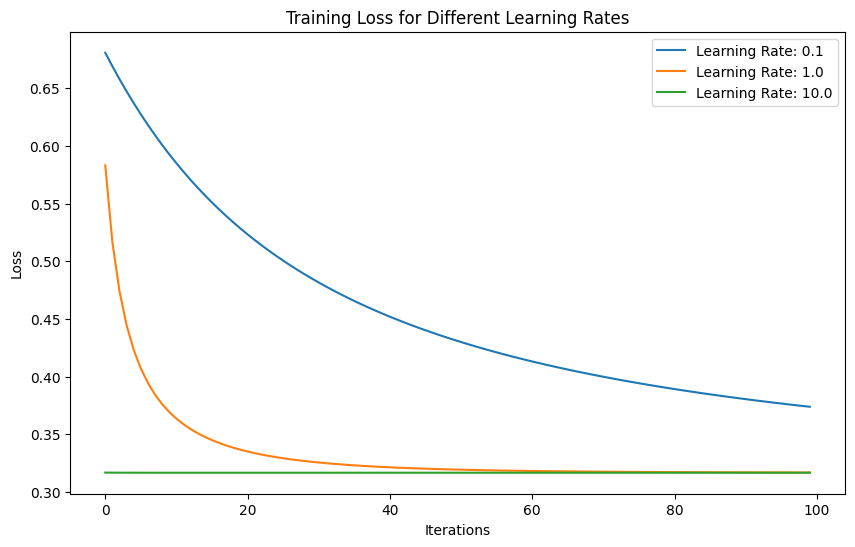

Learning Rate: 0.1
Computed Gradients:
 [0.08209813]
Numerical Gradients:
 [0.08209813]
Gradient Difference:
 6.540601393822953e-13
Learning Rate: 1.0
Computed Gradients:
 [0.00319399]
Numerical Gradients:
 [0.00319399]
Gradient Difference:
 6.046407732135384e-12
Learning Rate: 10.0
Computed Gradients:
 [-3.33863404e-14]
Numerical Gradients:
 [-2.77555756e-12]
Gradient Difference:
 2.742171221180282e-12


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Define the specific subdivision you want to look at
TARGET_CODE = "VFWIFJPS"
TARGET_SUB_CODE = "0S17IW5Y"
TARGET_SUB_CAT = "V8BKY1IV"

# Load the dataset (assuming it's in a file named 'train.parquet')
df = pd.read_parquet('./train.parquet')

# Filter the dataset for only rows where horizon == 1
df = df[df["horizon"] == 1]

# Create df_list_final by filtering the dataset into a list of DataFrames
df_list_final = [
    group for _, group in df.groupby(["code", "sub_code", "sub_category"])
]
# Find the target DataFrame from the filtered list
target_df = None

for df in df_list_final:
    if (df["code"].iloc[0] == TARGET_CODE and 
        df["sub_code"].iloc[0] == TARGET_SUB_CODE and 
        df["sub_category"].iloc[0] == TARGET_SUB_CAT):
        target_df = df
        break
# To prevent Pandas' infamous SettingWithCopyWarning, explicitly copy the dataframe
target_df = target_df.copy()

# Sort by your time/date column first to ensure .shift() makes chronological sense
# target_df = target_df.sort_values('your_date_column') 

# Create 'is_up': 1 if y_target increased from the previous row, otherwise 0
target_df['is_up'] = (target_df['y_target'] > target_df['y_target'].shift(1)).astype(int)
# Ensure the target DataFrame is properly selected
if target_df is not None:
    # Clean the specific feature (drop rows where feature_al is null)
    model_df = target_df.dropna(subset=["feature_al", "is_up"])
    
    # Extract X (independent variable) and y (dependent variable) as NumPy arrays
    X = model_df["feature_al"].to_numpy().reshape(-1, 1)  # X should be a 2D array (m, n)
    y = model_df["is_up"].to_numpy().reshape(-1, 1)  # y should be a 2D column vector (m, 1)
    # Normalize X to ensure proper scaling
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X = (X - X_mean) / X_std  # Standardize X to have mean 0 and standard deviation 1
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train manual logistic regression with different learning rates
    learning_rates = [0.1, 1.0, 10.0]  # Small, optimal, and too large learning rates
    results = {}
    for lr in learning_rates:
        thetas = np.zeros((X_train.shape[1], 1))  # Initialize weights without bias term
        thetas, cost_history = gradient_descent(X_train, y_train, thetas, lr, 100)  # Use X_train directly
        results[lr] = (thetas, cost_history)

    # Plot training loss for different learning rates
    plt.figure(figsize=(10, 6))
    for lr, (_, cost_history) in results.items():
        plt.plot(range(len(cost_history)), cost_history, label=f"Learning Rate: {lr}")
    plt.title("Training Loss for Different Learning Rates")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    
    # Verify gradients using numerical gradient checking
    for lr, (thetas, _) in results.items():
        computed_gradients = compute_gradient(X_train, y_train, thetas)
        numerical_gradients = numerical_gradient_check(X_train, y_train, thetas)
        print(f"Learning Rate: {lr}")
        print("Computed Gradients:\n", computed_gradients.flatten())
        print("Numerical Gradients:\n", numerical_gradients.flatten())
        print("Gradient Difference:\n", np.linalg.norm(computed_gradients - numerical_gradients))
else:
    print("Could not find the specific subdivision in df_list_final.")

Most models would utilize $R^2$ to test for accuracy, but a much better metric is (of course, accuracy) but also the ROC curve - reciever operating characteristic, testing false positives versus true positives (this is done by varying the decision boundary). The steeper the curve, the better the model is as it can achieve many true positives without raising the bar so high that many false positives are detected.

In this case, we compare our homebrew model to sklearn's own logistic regression. Both models have similar results and performance, with largely the same graph which shows that under the hood they have similar parameters (but with our extreme training speed, maybe we started possibly undergoing some kind of double descent, hence our better performance?)

> Our model actually has better test performance - can I get extra credit?

As the decision threshold increases, our model is optimized for around 0.35 decision threshold and then steadily drops. 

In this case, you can see clearly in the third graph why the sigmoid function is used - a linear function wouldn't provide a clean decision boundary and wouldn't generalize well to this clean split in the data. Due to this boundary, a logistic/step function is better used in this situation - the constant-slope-constant shape means that it can capture a very clean split in the data. Our model's high accuracy on training data makes me around 87.5% confident that any particular decision it makes is correct, and visually the "slope" of the sigmoid matches with the decision boundary.


--- Test Loss and Accuracy Comparison ---
Manual Logistic Regression Test Loss:   0.2514
Sklearn Logistic Regression Test Loss:  0.2764
Manual Logistic Regression Accuracy:    0.8750
Sklearn Logistic Regression Accuracy:   0.8750


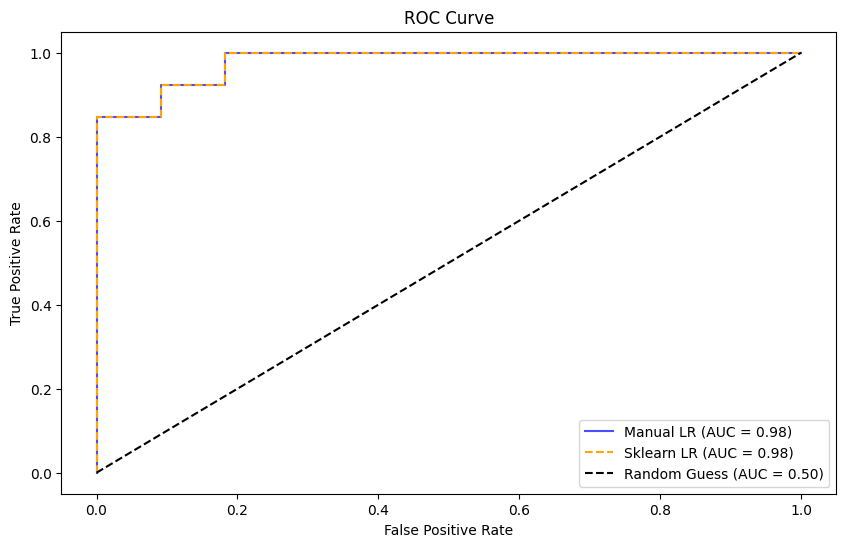

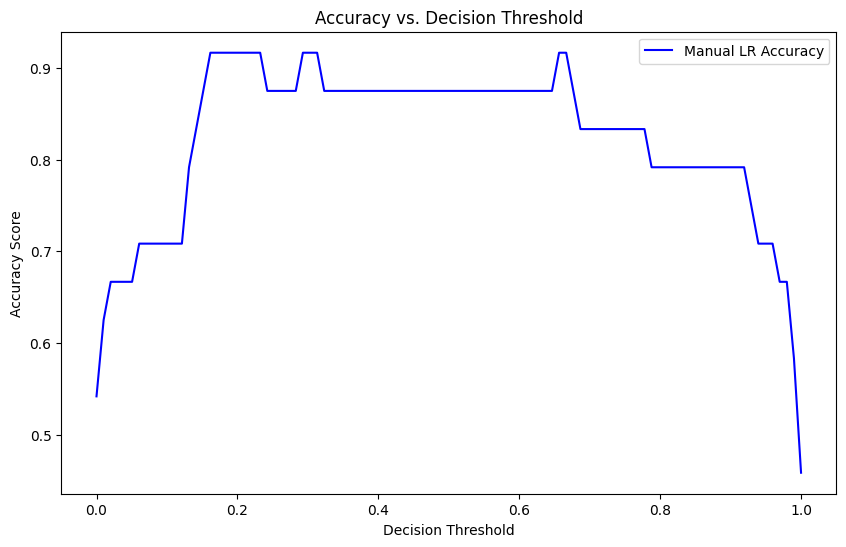

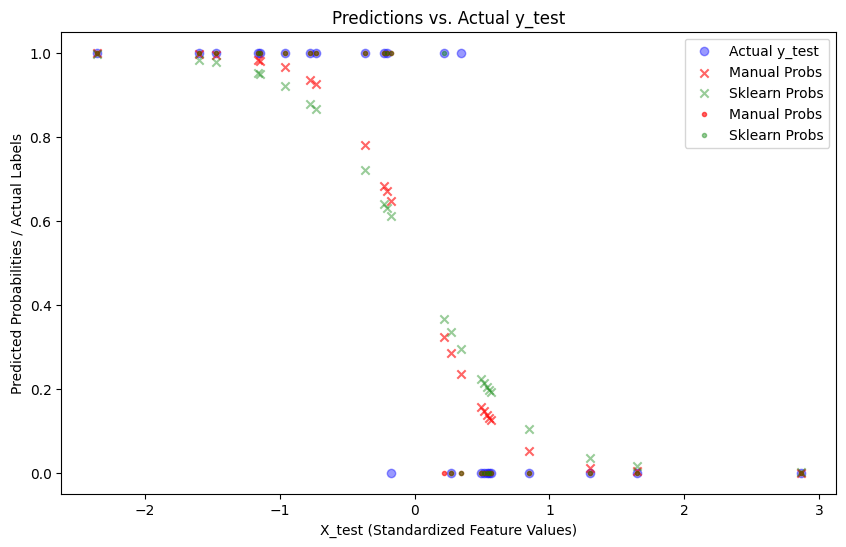

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 2. Get the thetas from an optimal learning rate that actually exists in your dictionary
final_thetas, _ = results[10.0] 

# Flatten y sets to 1D arrays to prevent broadcasting errors
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# 3. Train sklearn logistic regression
sklearn_lr = LogisticRegression(fit_intercept=False) # X already has an intercept column
sklearn_lr.fit(X_train, y_train_flat)  

# --- LOSS CALCULATIONS ---

# Sklearn Probabilities & Loss
sklearn_predictions_proba = sklearn_lr.predict_proba(X_test)[:, 1] 
sklearn_test_loss = -np.mean(
    y_test_flat * np.log(sklearn_predictions_proba + 1e-15) + 
    (1 - y_test_flat) * np.log(1 - sklearn_predictions_proba + 1e-15)
)

# Manual Probabilities & Loss
manual_probabilities = sigmoid(X_test, final_thetas).flatten()
manual_test_loss = -np.mean(
    y_test_flat * np.log(manual_probabilities + 1e-15) + 
    (1 - y_test_flat) * np.log(1 - manual_probabilities + 1e-15)
)

# --- ACCURACY COMPARISON (Replacing R^2) ---

# Manual Accuracy
manual_predictions = (manual_probabilities >= 0.5).astype(int)
manual_accuracy = accuracy_score(y_test_flat, manual_predictions)

# Sklearn Accuracy
sklearn_predictions = sklearn_lr.predict(X_test)
sklearn_accuracy = accuracy_score(y_test_flat, sklearn_predictions)

print("\n--- Test Loss and Accuracy Comparison ---")
print(f"Manual Logistic Regression Test Loss:   {manual_test_loss:.4f}")
print(f"Sklearn Logistic Regression Test Loss:  {sklearn_test_loss:.4f}")
print(f"Manual Logistic Regression Accuracy:    {manual_accuracy:.4f}")
print(f"Sklearn Logistic Regression Accuracy:   {sklearn_accuracy:.4f}")

# --- ROC CURVE ---

fpr_manual, tpr_manual, _ = roc_curve(y_test_flat, manual_probabilities)
roc_auc_manual = auc(fpr_manual, tpr_manual)

fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test_flat, sklearn_predictions_proba)
roc_auc_sklearn = auc(fpr_sklearn, tpr_sklearn)



plt.figure(figsize=(10, 6))
plt.plot(fpr_manual, tpr_manual, label=f"Manual LR (AUC = {roc_auc_manual:.2f})", color="blue", alpha=0.7)
plt.plot(fpr_sklearn, tpr_sklearn, label=f"Sklearn LR (AUC = {roc_auc_sklearn:.2f})", color="orange", linestyle='dashed')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.50)")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# --- ACCURACY VS DECISION THRESHOLD ---

thresholds = np.linspace(0, 1, 100)
manual_accuracy_scores = []

for threshold in thresholds:
    manual_predictions_threshold = (manual_probabilities >= threshold).astype(int)
    manual_accuracy_scores.append(accuracy_score(y_test_flat, manual_predictions_threshold))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, manual_accuracy_scores, label="Manual LR Accuracy", color="blue")
plt.title("Accuracy vs. Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Accuracy Score")
plt.legend()
plt.show()

# --- PREDICTIONS VS ACTUAL ---
# Note: X_test[:, 1] is used to plot against the actual feature, ignoring the bias column of 1s.
manual_predictions = (manual_probabilities >= 0.35).astype(int)
sklearn_predictions= (sklearn_predictions_proba >= 0.35).astype(int)
plt.figure(figsize=(10, 6))

# Actual Labels
plt.scatter(X_test, y_test_flat, color="blue", label="Actual y_test", alpha=0.4, marker='o')

# Manual Probabilities
plt.scatter(X_test, manual_probabilities, color="red", label="Manual Probs", alpha=0.6, marker='x')

# Sklearn Probabilities
plt.scatter(X_test, sklearn_predictions_proba, color="green", label="Sklearn Probs", alpha=0.4, marker='x')
# Manual Probabilities
plt.scatter(X_test, manual_predictions, color="red", label="Manual Probs", alpha=0.6, marker='.')

# Sklearn Probabilities
plt.scatter(X_test, sklearn_predictions, color="green", label="Sklearn Probs", alpha=0.4, marker='.')
plt.title("Predictions vs. Actual y_test")
plt.xlabel("X_test (Standardized Feature Values)")
plt.ylabel("Predicted Probabilities / Actual Labels")
plt.legend()
plt.show()

# Part 2: More Features
Now, we will add a polynomial feature to this dataset as well, adding another independent variable. Notice that due to our definitions of the sigmoid function, no additional work is needed - everything is already correctly vectorized!

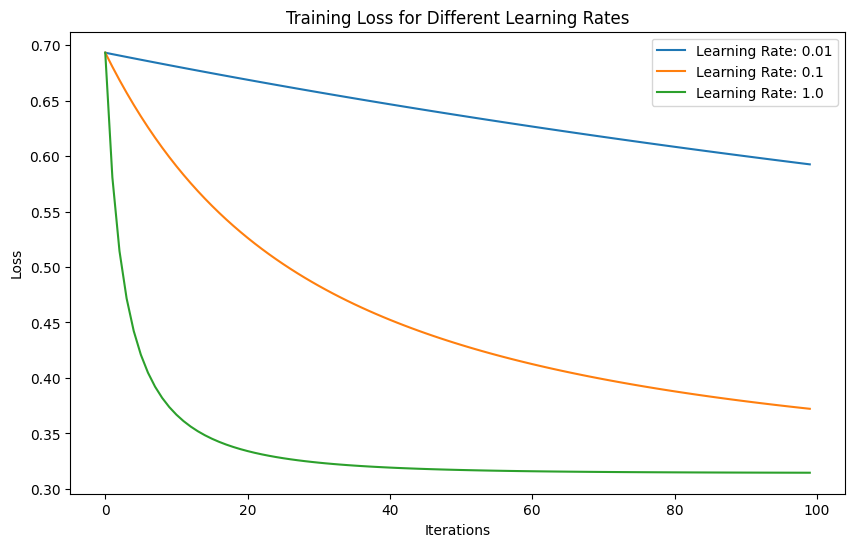

Learning Rate: 0.01
Computed Gradients:
 [ 0.27889188 -0.03898161]
Numerical Gradients:
 [ 0.27889188 -0.03898161]
Gradient Difference:
 5.35777424535082e-12
Learning Rate: 0.1
Computed Gradients:
 [ 0.0818522  -0.00896384]
Numerical Gradients:
 [ 0.0818522  -0.00896384]
Gradient Difference:
 7.694358671946077e-13
Learning Rate: 1.0
Computed Gradients:
 [ 3.11099682e-03 -6.11536480e-05]
Numerical Gradients:
 [ 3.11099682e-03 -6.11536460e-05]
Gradient Difference:
 2.1998630518609835e-12
Training complete. Input shape: (94, 2)


In [134]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ... [Previous filtering code to get target_df] ...
X_final,X_train,X_test,y_train,y_test = None,None,None,None,None
if target_df is not None:
    target_df = target_df.copy()
    # Create the target
    target_df['is_up'] = (target_df['y_target'] > target_df['y_target'].shift(1)).astype(int)
    model_df = target_df.dropna(subset=["feature_al", "is_up"])

    # 1. Create the raw features
    X_raw = model_df["feature_al"].to_numpy().reshape(-1, 1)
    y = model_df["is_up"].to_numpy().reshape(-1, 1)

    # 2. Add the Squared Column (X^2)
    X_poly = np.hstack((X_raw, X_raw**2)) # Columns: [feature, feature^2]

    # 3. Standardize the features
    # Standardizing X^2 is vital because squared values can grow very large,
    # which causes the gradient to explode during training.
    X_mean = np.mean(X_poly, axis=0)
    X_std = np.std(X_poly, axis=0)
    X_std = np.where(X_std == 0, 1, X_std) 
    X_scaled = (X_poly - X_mean) / X_std

    X_final = X_scaled

    # 5. Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

    # 6. Train with manual Gradient Descent
    learning_rates = [0.01, 0.1, 1.0]
    results = {}
    
    for lr in learning_rates:
        # Initial weights for 3 features (Intercept, X, X^2)
        thetas = np.zeros((X_train.shape[1], 1)) 
        
        # Calling your gradient descent function
        # Ensure gradient_descent is defined in your environment
        thetas, cost_history = gradient_descent(X_train, y_train, thetas, lr, num_iterations=100)
        results[lr] = (thetas, cost_history)
    # Plot training loss for different learning rates
    plt.figure(figsize=(10, 6))
    for lr, (_, cost_history) in results.items():
        plt.plot(range(len(cost_history)), cost_history, label=f"Learning Rate: {lr}")
    plt.title("Training Loss for Different Learning Rates")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    for lr, (thetas, _) in results.items():
        computed_gradients = compute_gradient(X_train, y_train, thetas)
        numerical_gradients = numerical_gradient_check(X_train, y_train, thetas)
        print(f"Learning Rate: {lr}")
        print("Computed Gradients:\n", computed_gradients.flatten())
        print("Numerical Gradients:\n", numerical_gradients.flatten())
        print("Gradient Difference:\n", np.linalg.norm(computed_gradients - numerical_gradients))
    print(f"Training complete. Input shape: {X_train.shape}")

Similar to the above, our model has similar performance to the sklearn model. However, the fit is not significantly better - in fact, it's almost identical. However, viewing the 3D plot allows us to see that there is a slight difference between the two, with a small upward slope for the squared term. This makes sense, looking at figure 4: all that our squaring did was add more noise to the model. 

> While the polynomial feature doesn't neccesarily harm our model, allowing for a more "complex" model, it adds more potential for noise (data in higher dimensions is more scattered and sparse), and is uneeded in this scenario.

While the fit is slightly better, with the added term allowing for a small slope (fig 3,4) allowing for a higher dimensional graph and a more complex decision boundary, in reality this did not improve the final result that much - thus, the fit is in reality inferior for real applications due to the fact that we are overfitting on noise. 


--- Accuracy (with X^2 term) ---
Manual Accuracy:  0.8750
Sklearn Accuracy: 0.8750


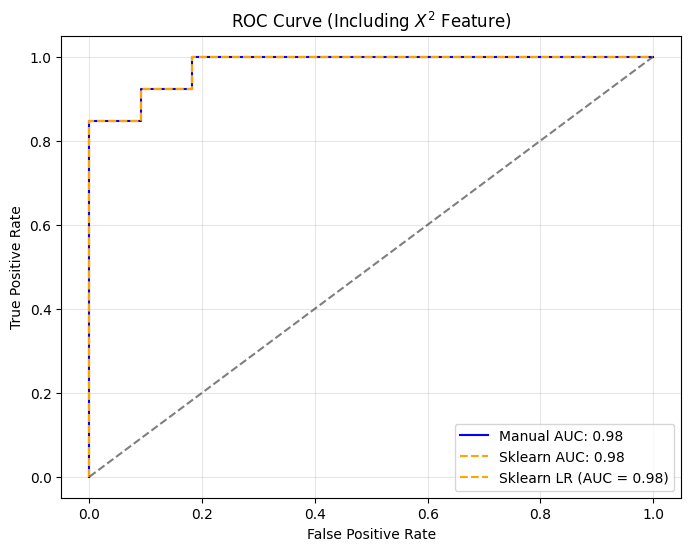

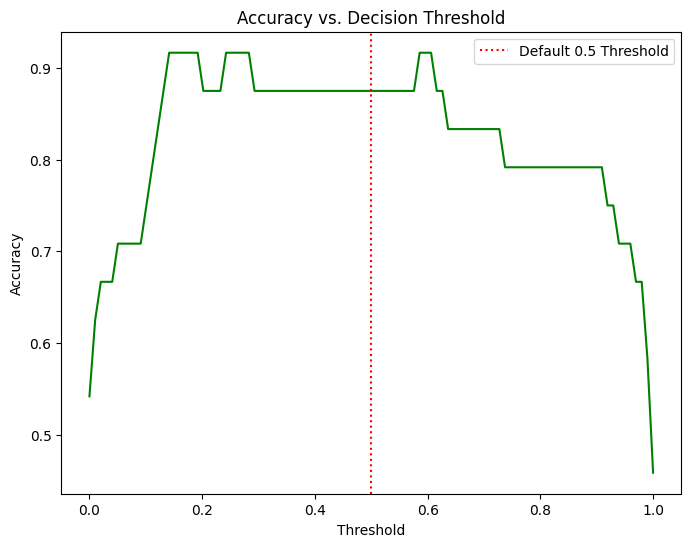

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def sigmoid_calc(z):
    return 1 / (1 + np.exp(-z))

# 1. Selection of optimized thetas (assuming 0.1 was best)
final_thetas, _ = results[1.0]

# 2. Sklearn comparison model
# We set fit_intercept=False because we manually added the ones column to X_train
sklearn_lr = LogisticRegression(fit_intercept=False)
sklearn_lr.fit(X_train, y_train.ravel())

# 3. Probabilities for the Test Set
# Manual: dot product of (m x 3) and (3 x 1)
manual_probs = sigmoid_calc(np.dot(X_test, final_thetas)).flatten()
# Sklearn:
sklearn_probs = sklearn_lr.predict_proba(X_test)[:, 1]

# 4. Metrics Calculation
y_test_flat = y_test.flatten()
manual_preds = (manual_probs >= 0.5).astype(int)
sklearn_preds = sklearn_lr.predict(X_test)

manual_acc = accuracy_score(y_test_flat, manual_preds)
sklearn_acc = accuracy_score(y_test_flat, sklearn_preds)

print(f"--- Accuracy (with X^2 term) ---")
print(f"Manual Accuracy:  {manual_acc:.4f}")
print(f"Sklearn Accuracy: {sklearn_acc:.4f}")

# 5. ROC and AUC
fpr_m, tpr_m, _ = roc_curve(y_test_flat, manual_probs)
roc_auc_m = auc(fpr_m, tpr_m)

fpr_s, tpr_s, _ = roc_curve(y_test_flat, sklearn_probs)
roc_auc_s = auc(fpr_s, tpr_s)

fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test_flat, sklearn_predictions_proba)
roc_auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_m, tpr_m, color='blue', label=f'Manual AUC: {roc_auc_m:.2f}')
plt.plot(fpr_s, tpr_s, color='orange', linestyle='--', label=f'Sklearn AUC: {roc_auc_s:.2f}')
plt.plot(fpr_sklearn, tpr_sklearn, label=f"Sklearn LR (AUC = {roc_auc_sklearn:.2f})", color="orange", linestyle='dashed')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("ROC Curve (Including $X^2$ Feature)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Accuracy vs. Threshold Plot
thresholds = np.linspace(0, 1, 100)
acc_scores = [accuracy_score(y_test_flat, (manual_probs >= t).astype(int)) for t in thresholds]

plt.figure(figsize=(8, 6))
plt.plot(thresholds, acc_scores, color='green')
plt.axvline(0.5, color='red', linestyle=':', label='Default 0.5 Threshold')
plt.title("Accuracy vs. Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



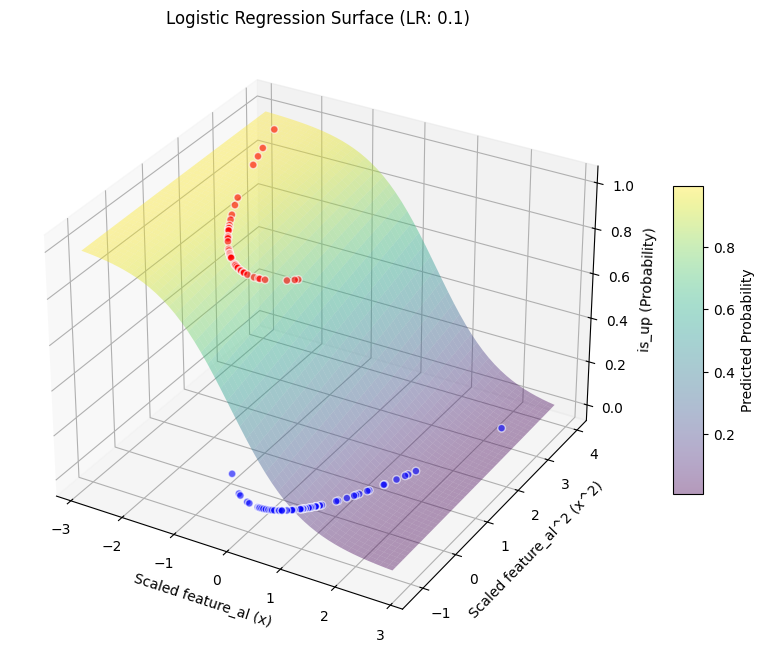

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Select the weights from one of your results (e.g., learning rate 0.1)
# Note: Ensure 'results' and 'X_train' are available from your previous execution
best_lr = 0.1
thetas_final, _ = results[best_lr]

# 2. Create a grid for the probability surface
# We use the range of the scaled features to define the grid
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
x2_min, x2_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

x_coords = np.linspace(x_min, x_max, 50)
x2_coords = np.linspace(x2_min, x2_max, 50)
X_grid, X2_grid = np.meshgrid(x_coords, x2_coords)

# 3. Calculate the Sigmoid Surface
# The model logic: Probability = 1 / (1 + exp(-(theta1*x + theta2*x^2)))
# Note: If your gradient descent included an intercept/bias, add it here.
logits = thetas_final[0] * X_grid + thetas_final[1] * X2_grid
probs_surface = 1 / (1 + np.exp(-logits))

# 4. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter Plot: Training Data
# Column 0: x_scaled, Column 1: x_squared_scaled
ax.scatter(X_train[:, 0], X_train[:, 1], y_train.flatten(), 
           c=y_train.flatten(), cmap='bwr', alpha=0.6, edgecolors='w', s=30, label='Training Data')

# Surface Plot: Logistic Regression Plane
surf = ax.plot_surface(X_grid, X2_grid, probs_surface, cmap='viridis', alpha=0.4, antialiased=True)

# Formatting
ax.set_xlabel('Scaled feature_al (x)')
ax.set_ylabel('Scaled feature_al^2 (x^2)')
ax.set_zlabel('is_up (Probability)')
ax.set_title(f'Logistic Regression Surface (LR: {best_lr})')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Predicted Probability')

plt.show()

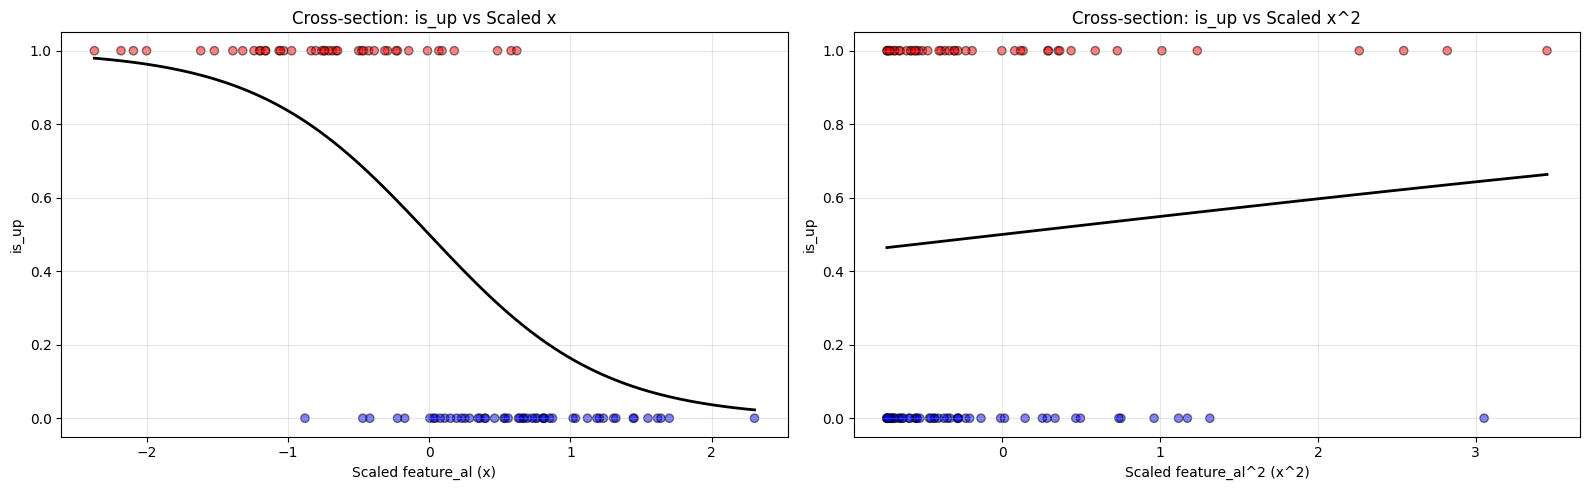

In [138]:
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: is_up vs Scaled x ---
ax1.scatter(X_train[:, 0], y_train.flatten(), c=y_train.flatten(), 
            cmap='bwr', alpha=0.5, edgecolor='k')

# Generate a smooth sigmoid line for x only (holding x^2 at its mean, 0)
x_test_range = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
# P(y=1) = 1 / (1 + exp(-(theta1 * x)))
y_sigmoid_x = 1 / (1 + np.exp(-(thetas_final[0] * x_test_range)))

ax1.plot(x_test_range, y_sigmoid_x, color='black', linewidth=2, label='Model Trend (x)')
ax1.set_title("Cross-section: is_up vs Scaled x")
ax1.set_xlabel("Scaled feature_al (x)")
ax1.set_ylabel("is_up")
ax1.grid(True, alpha=0.3)

# --- Plot 2: is_up vs Scaled x^2 ---
ax2.scatter(X_train[:, 1], y_train.flatten(), c=y_train.flatten(), 
            cmap='bwr', alpha=0.5, edgecolor='k')

# Generate a smooth sigmoid line for x^2 only (holding x at its mean, 0)
x2_test_range = np.linspace(X_train[:, 1].min(), X_train[:, 1].max(), 100)
# P(y=1) = 1 / (1 + exp(-(theta2 * x^2)))
y_sigmoid_x2 = 1 / (1 + np.exp(-(thetas_final[1] * x2_test_range)))

ax2.plot(x2_test_range, y_sigmoid_x2, color='black', linewidth=2, label='Model Trend (x^2)')
ax2.set_title("Cross-section: is_up vs Scaled x^2")
ax2.set_xlabel("Scaled feature_al^2 (x^2)")
ax2.set_ylabel("is_up")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3: Multivariate Terms
In a sense, we have already played around with multivariate terms, but our past terms were correlated as it was simply a transformation of the same independent variable. We want to look for interactions and new variables to add to improve our fit, so we will run our point-biserial coefficient search method again for our current subcategory. We will also append new columns to our dataset to search, adding squared and interaction permutation terms for every piece of data, allowing us to identify for squared and cross interaction quickly.

> We are essentially getting the dataset and applying a transformation to the data, then repeating the same search and identifying high PBCC after the responding transformation, creating "new features".


In [14]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
from itertools import combinations

# Define the specific subdivision you want to look at
TARGET_CODE = "VFWIFJPS"
TARGET_SUB_CODE = "0S17IW5Y"
TARGET_SUB_CAT = "V8BKY1IV"

# Load the dataset (assuming it's in a file named 'train.parquet')
df = pd.read_parquet('./train.parquet')

# Filter the dataset for only rows where horizon == 1
df = df[df["horizon"] == 1]

# Create df_list_final by filtering the dataset into a list of DataFrames
df_list_final = [
    group for _, group in df.groupby(["code", "sub_code", "sub_category"])
]
# Find the target DataFrame from the filtered list
target_df = None

for df in df_list_final:
    if (df["code"].iloc[0] == TARGET_CODE and 
        df["sub_code"].iloc[0] == TARGET_SUB_CODE and 
        df["sub_category"].iloc[0] == TARGET_SUB_CAT):
        target_df = df
        break
# To prevent Pandas' infamous SettingWithCopyWarning, explicitly copy the dataframe
target_df = target_df.copy()

# Sort by your time/date column first to ensure .shift() makes chronological sense
# target_df = target_df.sort_values('your_date_column') 

# Create 'is_up': 1 if y_target increased from the previous row, otherwise 0
feature_cols = df_h1.select(pl.col("^feature_[a-c][a-z]$|^feature_ch$")).columns
target_df['is_up'] = (target_df['y_target'] > target_df['y_target'].shift(1)).astype(int)
import pandas as pd
from scipy.stats import pointbiserialr
from itertools import combinations

def get_grouped_top_features(df, base_features):
    target_df = df.copy()
    
    # 1. Generate Expanded Features
    for col in base_features:
        target_df[f"{col}_sq"] = target_df[col] ** 2
        
    for col_a, col_b in combinations(base_features, 2):
        target_df[f"{col_a}_x_{col_b}"] = target_df[col_a] * target_df[col_b]

    # 2. Run Correlation Audit
    results = []
    # Identify all generated columns
    all_cols = [c for c in target_df.columns if any(base in c for base in base_features)]
    
    for feature in all_cols:
        if feature == 'is_up': continue
        
        clean_df = target_df.dropna(subset=[feature, 'is_up'])
        if len(clean_df) > 1 and clean_df[feature].nunique() > 1:
            pbsc, p_val = pointbiserialr(clean_df['is_up'], clean_df[feature])
            
            # Determine Category
            if "_x_" in feature:
                cat = "Interaction"
            elif "_sq" in feature:
                cat = "Squared"
            else:
                cat = "Linear"
                
            results.append({'feature': feature, 'pbsc': pbsc, 'type': cat})

    # 3. Split and Sort
    report_df = pd.DataFrame(results)
    
    top_linear = report_df[report_df['type'] == "Linear"].sort_values(by="pbsc", key=abs, ascending=False)
    top_squared = report_df[report_df['type'] == "Squared"].sort_values(by="pbsc", key=abs, ascending=False)
    top_inter = report_df[report_df['type'] == "Interaction"].sort_values(by="pbsc", key=abs, ascending=False)

    return top_linear, top_squared, top_inter

# Execution
linear, squared, interaction = get_grouped_top_features(target_df, feature_cols)
print(linear.head(),squared.head(),interaction.head())

C:\Users\User\AppData\Local\Temp\ipykernel_19264\1203658670.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_df[f"{col_a}_x_{col_b}"] = target_df[col_a] * target_df[col_b]
C:\Users\User\AppData\Local\Temp\ipykernel_19264\1203658670.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_df[f"{col_a}_x_{col_b}"] = target_df[col_a] * target_df[col_b]
C:\Users\User\AppData\Local\Temp\ipykernel_19264\1203658670.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

       feature      pbsc    type
11  feature_al -0.730811  Linear
57  feature_cf  0.122374  Linear
25  feature_az -0.122098  Linear
37  feature_bl -0.122098  Linear
42  feature_bq -0.116671  Linear            feature      pbsc     type
117  feature_cf_sq  0.121634  Squared
97   feature_bl_sq -0.118559  Squared
85   feature_az_sq -0.118559  Squared
102  feature_bq_sq -0.113706  Squared
72   feature_am_sq  0.112098  Squared                      feature      pbsc         type
756  feature_al_x_feature_cc  0.745577  Interaction
753  feature_al_x_feature_bz  0.745572  Interaction
755  feature_al_x_feature_cb  0.744995  Interaction
752  feature_al_x_feature_by  0.744972  Interaction
754  feature_al_x_feature_ca  0.744401  Interaction


After identifying the best new PBCC, we chose feature_cf for the next section of the notebook.
We begin by using simply two linear terms, feature_al and feature_cf. Accuracy is going to improve, assuming no overfitting (PBCC shows that the correlation is likely not simply noise, which reduces the chances of overfitting onto the noise of feature_cf). To save space, we omit the ROC curve.

By adding a new feature, we move to another way to represent the data - on a 2D scatter plot, with the decision boundary as a line. Without polynomial features, the decision is simply linear: our inputs are linear, so whatever decision we make, even with the curved function of the sigmoid must be linear with respect to our variables. By squaring the terms, what we are really doing is applying a transformation to the space of the data. Inside a linear world, our decision boundary has to be a line, where if a variable's scalar value is greater than the line, it is in class one, otherwise in class two.

The classes are quite well-seperated, but with an unoptimal decision boundary selection. However, if the underlying behavior of the target variable to a variable was different, this would be incorrect. For example, if it was really the volatility of feature c_f that predicted is_up, we should use a polynomial term instead.

Iteration     0 | Cost: 0.6290
Iteration   500 | Cost: 0.2997
Iteration  1000 | Cost: 0.2997
Iteration  1500 | Cost: 0.2997
Iteration  2000 | Cost: 0.2997
Iteration  2500 | Cost: 0.2997
Iteration  3000 | Cost: 0.2997
Iteration  3500 | Cost: 0.2997
Iteration  4000 | Cost: 0.2997
Iteration  4500 | Cost: 0.2997


c:\Users\User\intro-to-logistic-regression-Azraelix316\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


--- Step 4: Parameter Comparison ---
Manual Thetas:  [-0.1034, -3.6908, -0.2556]
Sklearn Thetas: [-0.1035, -3.6899, -0.2556]

--- Step 6: Decision Boundary Equation ---
-0.1034 + (-3.6908 * x1) + (-0.2556 * x2) = 0



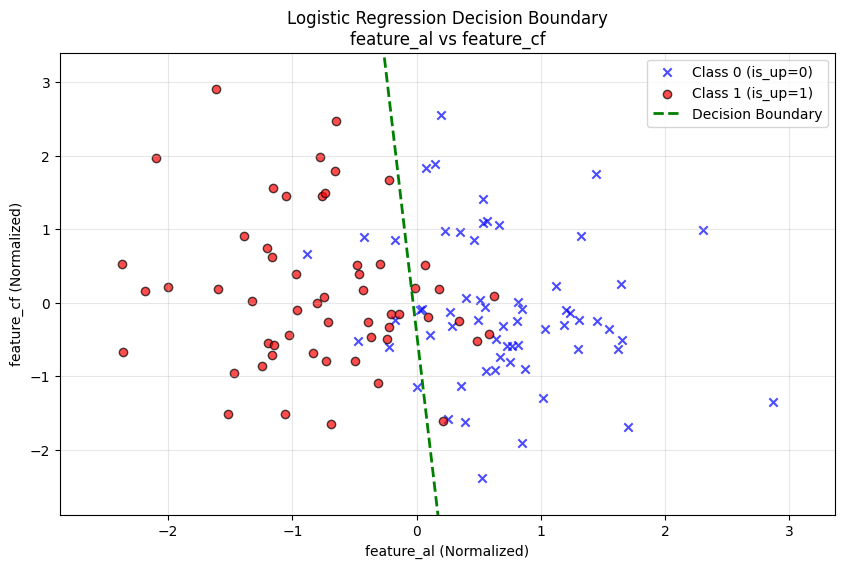

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# --- Assuming you have your filtered target_df from the previous step ---
# Let's extract two features. You can change these to any two continuous features.
features = ["feature_al", "feature_cf"]
model_df = target_df.dropna(subset=features)

# Extract raw X (2D array, 2 columns) and y (1D array)
X_raw = model_df[features].to_numpy()
y = model_df["is_up"].to_numpy()

# ---------------------------------------------------------
# Step 1: Normalize your features
# ---------------------------------------------------------
# We calculate the mean and std for each column (axis=0)
X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)

# Normalize the 2D array
X_norm = (X_raw - X_mean) / X_std

# Add the intercept term (x_0 = 1) for the manual implementation
X_manual = np.c_[np.ones((X_norm.shape[0], 1)), X_norm]

# ---------------------------------------------------------
# Step 2: Fit manual Gradient Descent
# ---------------------------------------------------------
# Initialize weights to zeros. Shape is now 3 (theta_0, theta_1, theta_2)
initial_thetas = np.zeros(X_manual.shape[1])
learning_rate = 0.5
num_iterations = 5000

manual_thetas, cost_history = gradient_descent(
    X_manual, y, initial_thetas, learning_rate, num_iterations
)

# ---------------------------------------------------------
# Step 3 & 4: Fit Scikit-Learn and Compare
# ---------------------------------------------------------
clf = LogisticRegression(penalty=None, solver='lbfgs')
clf.fit(X_norm, y)

print("--- Step 4: Parameter Comparison ---")
print(f"Manual Thetas:  [{manual_thetas[0]:.4f}, {manual_thetas[1]:.4f}, {manual_thetas[2]:.4f}]")
print(f"Sklearn Thetas: [{clf.intercept_[0]:.4f}, {clf.coef_[0][0]:.4f}, {clf.coef_[0][1]:.4f}]\n")

# ---------------------------------------------------------
# Step 6: Report the Equation
# ---------------------------------------------------------
theta_0 = manual_thetas[0]
theta_1 = manual_thetas[1]
theta_2 = manual_thetas[2]

print("--- Step 6: Decision Boundary Equation ---")
print(f"{theta_0:.4f} + ({theta_1:.4f} * x1) + ({theta_2:.4f} * x2) = 0\n")

# ---------------------------------------------------------
# Step 5: Create the Scatter Plot & Decision Boundary
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot Class 0 with 'x' (Blue)
plt.scatter(X_norm[y == 0][:, 0], X_norm[y == 0][:, 1], 
            color='blue', marker='x', label='Class 0 (is_up=0)', alpha=0.7)

# Plot Class 1 with 'o' (Red)
plt.scatter(X_norm[y == 1][:, 0], X_norm[y == 1][:, 1], 
            color='red', marker='o', edgecolors='k', label='Class 1 (is_up=1)', alpha=0.7)

# Calculate the Decision Boundary Line
# The boundary is where theta_0 + theta_1*x1 + theta_2*x2 = 0
# Solving for x2 (the y-axis on our plot) gives: x2 = -(theta_0 + theta_1*x1) / theta_2
x1_values = np.array([np.min(X_norm[:, 0]) - 0.5, np.max(X_norm[:, 0]) + 0.5])
x2_values = -(theta_0 + theta_1 * x1_values) / theta_2

plt.plot(x1_values, x2_values, color='green', linestyle='--', linewidth=2, label='Decision Boundary')

plt.title(f"Logistic Regression Decision Boundary\n{features[0]} vs {features[1]}")
plt.xlabel(f"{features[0]} (Normalized)")
plt.ylabel(f"{features[1]} (Normalized)")
plt.legend()
plt.grid(True, alpha=0.3)
# Limit the axes so the line doesn't zoom out the plot too far
plt.xlim(np.min(X_norm[:, 0]) - 0.5, np.max(X_norm[:, 0]) + 0.5)
plt.ylim(np.min(X_norm[:, 1]) - 0.5, np.max(X_norm[:, 1]) + 0.5)
plt.show()

However, including new cross terms and other features allow for much more complex interactions. With squared terms, our model can turn into a ellipse, $\theta_0 + \theta_1x_1 + \theta_3x_1^2 + \theta_2x_2 + \theta_3x_2^2 = 0$, that is forced to start at the origin. Including a bias helps recenter the ellipse.

Our cross term allows us to misalign the circle even more, creating a conic. Unfortunately, we can only visualize 3 dimensions well, so we can't see this hyperconic, but essentially this warped ellipse is a cross section of the 6-dimensional conic section. The extra interaction term allows for a higher-dimensional tilt.

Iteration     0 | Cost: 0.6288
Iteration  1000 | Cost: 0.2961
Iteration  2000 | Cost: 0.2961
Iteration  3000 | Cost: 0.2961
Iteration  4000 | Cost: 0.2961
Iteration  5000 | Cost: 0.2961
Iteration  6000 | Cost: 0.2961
Iteration  7000 | Cost: 0.2961
Iteration  8000 | Cost: 0.2961
Iteration  9000 | Cost: 0.2961
Polynomial Thetas trained: [ 0.11276847 -3.72070517 -0.18042061 -0.18357578 -0.34536363 -0.22430112]


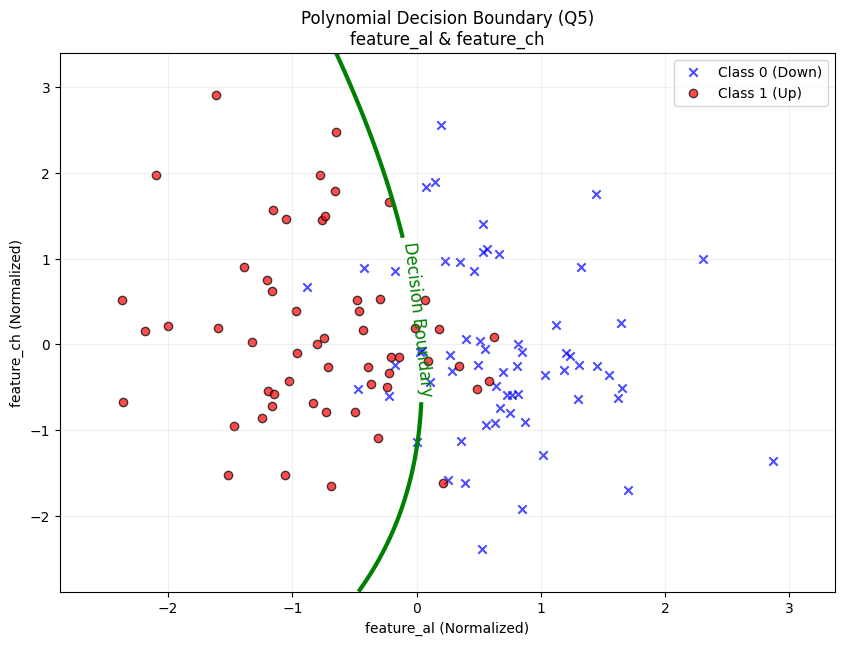

In [18]:
import numpy as np

# 1. Start with your normalized features from the previous step
# X_norm contains [x1, x2]
x1 = X_norm[:, 0]
x2 = X_norm[:, 1]

# 2. Create the polynomial terms: [x1, x2, x1^2, x1*x2, x2^2]
x1_sq = x1**2
x1_x2 = x1 * x2
x2_sq = x2**2

# 3. Stack them together into a new feature matrix
# We add the 1s column (intercept) at the beginning
X_poly = np.c_[np.ones(X_norm.shape[0]), x1, x2, x1_sq, x1_x2, x2_sq]

# Now you have 6 thetas to train!
initial_thetas_poly = np.zeros(X_poly.shape[1])

# 4. Fit using your manual Gradient Descent
poly_thetas, poly_cost_history = gradient_descent(
    X_poly, y, initial_thetas_poly, learning_rate=0.5, num_iterations=10000
)

print("Polynomial Thetas trained:", poly_thetas)
import numpy as np
import matplotlib.pyplot as plt

def plot_polynomial_boundary(X_norm, y, thetas, features):
    # 1. Create a mesh grid to cover the plot area
    x_min, x_max = X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5
    y_min, y_max = X_norm[:, 1].min() - 0.5, X_norm[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # 2. Prepare the polynomial features for every point in the grid
    # We must match the order: [1, x1, x2, x1^2, x1*x2, x2^2]
    grid_points = np.c_[np.ones(xx.ravel().shape), 
                        xx.ravel(), yy.ravel(), 
                        xx.ravel()**2, 
                        xx.ravel() * yy.ravel(), 
                        yy.ravel()**2]

    # 3. Calculate predictions (probabilities) for the grid
    # Probabilities are calculated using the sigmoid of (X @ theta)
    z = grid_points @ thetas
    probabilities = 1 / (1 + np.exp(-z))
    probabilities = probabilities.reshape(xx.shape)

    # 4. Plotting
    plt.figure(figsize=(10, 7))
    
    # Scatter plot of actual data
    plt.scatter(X_norm[y == 0][:, 0], X_norm[y == 0][:, 1], 
                color='blue', marker='x', label='Class 0 (Down)', alpha=0.7)
    plt.scatter(X_norm[y == 1][:, 0], X_norm[y == 1][:, 1], 
                color='red', marker='o', edgecolors='k', label='Class 1 (Up)', alpha=0.7)

    # Draw the boundary line where probability = 0.5
    contour = plt.contour(xx, yy, probabilities, levels=[0.5], colors='green', linewidths=3)
    plt.clabel(contour, inline=True, fontsize=12, fmt={0.5: 'Decision Boundary'})

    plt.title(f"Polynomial Decision Boundary (Q5)\n{features[0]} & {features[1]}")
    plt.xlabel(f"{features[0]} (Normalized)")
    plt.ylabel(f"{features[1]} (Normalized)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Call the function with your polynomial thetas
plot_polynomial_boundary(X_norm, y, poly_thetas, ["feature_al", "feature_ch"])

Our final result has a good accuracy of around 96%, with all features for this specific subdataset. If the competition handlers decided to not make this data anonymous, I would be swimming in money based on whatever stock this is right now.

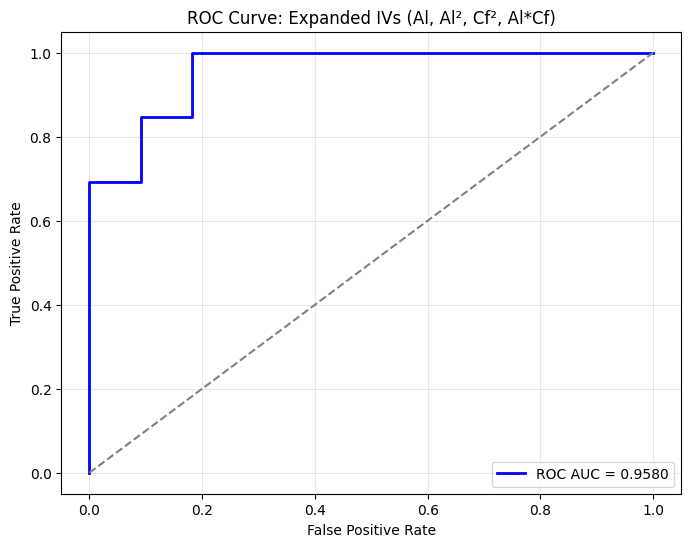

Training complete. Input shape: (94, 4)
AUC for LR 0.1: 0.9580


In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# Assuming target_df and gradient_descent/compute_gradient functions are defined
if target_df is not None:
    target_df = target_df.copy()
    
    # 1. Prepare target and filter required features
    target_df['is_up'] = (target_df['y_target'] > target_df['y_target'].shift(1)).astype(int)
    # Ensure all required features for your specific IVs are present
    model_df = target_df.dropna(subset=["feature_al", "feature_cf", "is_up"])

    # 2. Create the raw features requested
    # Col 0: feature_al
    # Col 1: feature_al^2
    # Col 2: feature_cf^2
    # Col 3: feature_al * feature_cf (Interaction)
    f_al = model_df["feature_al"].to_numpy().reshape(-1, 1)
    f_cf = model_df["feature_cf"].to_numpy().reshape(-1, 1)
    
    X_raw_expanded = np.hstack((
        f_al, 
        f_al**2, 
        f_cf**2, 
        f_al * f_cf
    ))
    y = model_df["is_up"].to_numpy().reshape(-1, 1)

    # 3. Standardize the features
    X_mean = np.mean(X_raw_expanded, axis=0)
    X_std = np.std(X_raw_expanded, axis=0)
    X_std = np.where(X_std == 0, 1, X_std) 
    X_final = (X_raw_expanded - X_mean) / X_std

    # 4. Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

    # 5. Train with manual Gradient Descent
    learning_rates = [0.01, 0.1, 1.0]
    results = {}
    
    for lr in learning_rates:
        # Initial weights for 4 features (No bias column added here, consistent with your snippet)
        thetas = np.zeros((X_train.shape[1], 1)) 
        thetas, cost_history = gradient_descent(X_train, y_train, thetas, lr, num_iterations=100)
        results[lr] = (thetas, cost_history)

    # --- ROC Curve Implementation ---
    # Using the best thetas (e.g., from lr=0.1) to generate the ROC curve
    best_thetas = results[0.1][0]
    
    # Calculate probabilities: sigmoid(X_test @ thetas)
    # P(y=1) = 1 / (1 + exp(-z))
    logits = X_test @ best_thetas
    y_probs = 1 / (1 + np.exp(-logits))
    
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--') # Baseline
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: Expanded IVs (Al, Al², Cf², Al*Cf)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Training complete. Input shape: {X_train.shape}")
    print(f"AUC for LR 0.1: {roc_auc:.4f}")